In [4]:
!pip install -q torch_snippets # instala biblioteca de utilitários
from torch_snippets import * # importa funções
from torchvision.datasets import MNIST # importa dataset
from torchvision import transforms # importa ferramentas
device = 'cuda' if torch.cuda.is_available() else 'cpu'

img_transform = transforms.Compose([ # agrupa várias transformações
    transforms.ToTensor(), # converte imagem para tensor
    transforms.Normalize([0.5], [0.5]), # ajusta media e desvio padrão
    transforms.Lambda(lambda x: x.to(device)) # envia o dado
])

trn_ds = MNIST('./content/', transform=img_transform, train=True, download=True) # cria dataset de treino
val_ds = MNIST('./content/', transform=img_transform, train=False, download=True) # cria dataset de validação

batch_size = 128 # define tamanho do lote de imagens
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True) # cria carregador de treino com sorteio
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False) # cria carregador de validação ordenado

In [5]:
class ConvAutoEncoder(nn.Module): # define classe
    def __init__(self): # inicializa a estrutura
        super().__init__()
        self.encoder = nn.Sequential( # inicia bloco
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2, stride=2), # reduz resolução
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2, stride=1) # reduz levemente
        )

        self.decoder = nn.Sequential( # inicia bloco
            nn.ConvTranspose2d(64, 32, 3, stride=2), nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, 5, stride=2, padding=1), nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, 2, stride=2, padding=1), nn.Tanh()
        )

    def forward(self, x): # define fluxo
        x = self.encoder(x) # compressor
        x = self.decoder(x) # reconstrutor
        return x # retorna

model = ConvAutoEncoder().to(device) # cria modelo
!pip install torch_summary # instala ferramenta
from torchsummary import summary # importa função
summary(model, torch.zeros(2, 1, 28, 28)) # exibe arquitetura

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 64, 3, 3]            --
|    └─Conv2d: 2-1                       [-1, 32, 14, 14]          320
|    └─ReLU: 2-2                         [-1, 32, 14, 14]          --
|    └─MaxPool2d: 2-3                    [-1, 32, 7, 7]            --
|    └─Conv2d: 2-4                       [-1, 64, 4, 4]            18,496
|    └─ReLU: 2-5                         [-1, 64, 4, 4]            --
|    └─MaxPool2d: 2-6                    [-1, 64, 3, 3]            --
├─Sequential: 1-2                        [-1, 1, 28, 28]           --
|    └─ConvTranspose2d: 2-7              [-1, 32, 7, 7]            18,464
|    └─ReLU: 2-8                         [-1, 32, 7, 7]            --
|    └─ConvTranspose2d: 2-9              [-1, 16, 15, 15]          12,816
|    └─ReLU: 2-10                        [-1, 16, 15, 15]          --
|    └─ConvTranspose2d: 2-11             [-1, 1, 28, 28]           65
| 

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 64, 3, 3]            --
|    └─Conv2d: 2-1                       [-1, 32, 14, 14]          320
|    └─ReLU: 2-2                         [-1, 32, 14, 14]          --
|    └─MaxPool2d: 2-3                    [-1, 32, 7, 7]            --
|    └─Conv2d: 2-4                       [-1, 64, 4, 4]            18,496
|    └─ReLU: 2-5                         [-1, 64, 4, 4]            --
|    └─MaxPool2d: 2-6                    [-1, 64, 3, 3]            --
├─Sequential: 1-2                        [-1, 1, 28, 28]           --
|    └─ConvTranspose2d: 2-7              [-1, 32, 7, 7]            18,464
|    └─ReLU: 2-8                         [-1, 32, 7, 7]            --
|    └─ConvTranspose2d: 2-9              [-1, 16, 15, 15]          12,816
|    └─ReLU: 2-10                        [-1, 16, 15, 15]          --
|    └─ConvTranspose2d: 2-11             [-1, 1, 28, 28]           65
| 

In [6]:
def train_batch(input,model,criterion,optimizer): # função de treino
    model.train()
    optimizer.zero_grad() # zera grad
    output = model(input) # gera reconstrução
    loss = criterion(output, input) # calcula erro
    loss.backward() # calcula grad
    optimizer.step() # atualiza os pesos
    return loss # retorna

In [7]:
@torch.no_grad() # desativa calculo
def validate_batch(input,model,criterion): # função de validação
    model.eval() # liga modo
    output = model(input) # reconstrução da imagem
    loss = criterion(output, input) # erro de validação
    return loss # retorna

In [8]:
model = ConvAutoEncoder().to(device) # cria modelo
criterion = nn.MSELoss() # define erro
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.001, weight_decay=1e-5)

In [9]:
from fastprogress import master_bar, progress_bar

num_epochs = 5
log = master_bar(range(num_epochs)) # cria barra de progresso mestre
for epoch in log: # inicia loop de épocas
    log.write(f"Epoch {epoch + 1}/{num_epochs} started.")

    N = len(trn_dl) # obtém total
    for ix, (data, _) in enumerate(progress_bar(trn_dl, parent=log)): # loop de treino
        loss = train_batch(data, model, criterion, optimizer) # executa passo de treino
        log.child.comment = f"Training Loss: {loss:.4f}" # mostra erro de treino atual

    N = len(val_dl) # obtém total de lotes de validação
    for ix, (data, _) in enumerate(progress_bar(val_dl, parent=log)): # loop de validação
        loss = validate_batch(data, model, criterion) # executa passo de validação
        log.child.comment = f"Validation Loss: {loss:.4f}"


    log.write(f"Epoch {epoch + 1}/{num_epochs} completed.")

<div><p>Epoch 1/5 started.</p><p>Epoch 1/5 completed.</p><p>Epoch 2/5 started.</p><p>Epoch 2/5 completed.</p><p>Epoch 3/5 started.</p><p>Epoch 3/5 completed.</p><p>Epoch 4/5 started.</p><p>Epoch 4/5 completed.</p><p>Epoch 5/5 started.</p><p>Epoch 5/5 completed.</p></div>

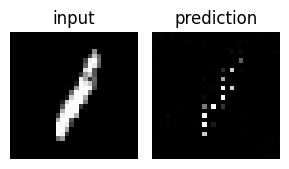

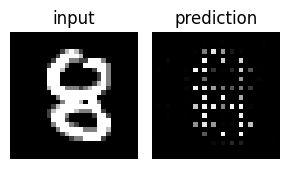

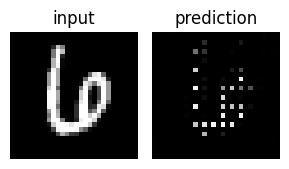

In [10]:
import matplotlib.pyplot as plt # importa biblioteca de gráficos

model.eval()

for _ in range(3): # repete o processo
    ix = np.random.randint(len(val_ds)) # sorteia um índice
    im, _ = val_ds[ix] # pega uma imagem do dataset

    im = im.to(device)

    with torch.no_grad(): # desativa cálculo de gradientes
        _im = model(im[None])[0].cpu() # gera reconstrução e volta para cpu

    fig, ax = plt.subplots(1, 2, figsize=(3, 3))
    show(im[0].cpu(), ax=ax[0], title='input') # mostra imagem original
    show(_im[0], ax=ax[1], title='prediction') # mostra imagem reconstruída
    plt.tight_layout()
    plt.show()

In [11]:
latent_vectors = []
classes = []

In [12]:
for im, clss in val_dl: # percorre lotes de validação
    im = im.to(device)
    with torch.no_grad():
        latent = model.encoder(im).view(im.size(0), -1) # extrai e achata o vetor
    latent_vectors.append(latent.cpu()) # salva vetores
    classes.append(clss) # salva as classe

In [13]:
latent_vectors = torch.cat(latent_vectors)

In [14]:
from sklearn.manifold import TSNE
tsne = TSNE(2)

In [15]:
clustered = tsne.fit_transform(latent_vectors.numpy())

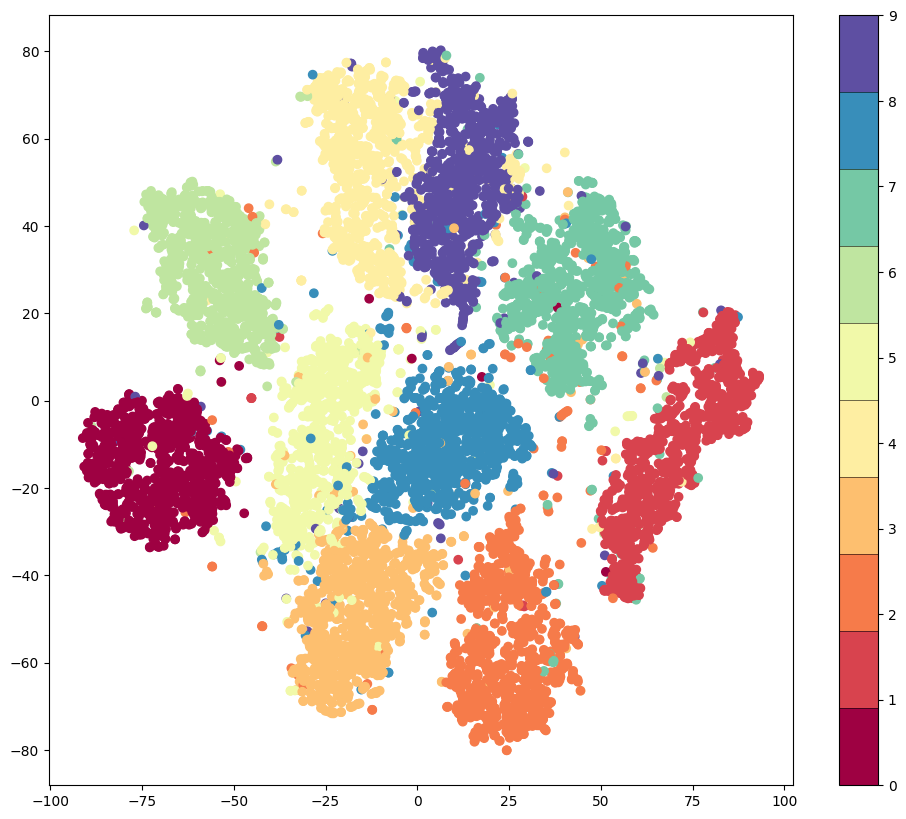

In [16]:
fig = plt.figure(figsize=(12, 10))
cmap = plt.get_cmap('Spectral', 10) # cria um mapa de cores
all_classes = torch.cat(classes).numpy() # Concatena todas as classes
plt.scatter(*zip(*clustered), c=all_classes, cmap=cmap)
plt.colorbar(drawedges=True)

In [17]:
latent_vectors = [] # lista vetores
classes = [] # lista classes
for im,clss in val_dl: # percorre o loader
    latent_vectors.append(model.encoder(im))
    classes.extend(clss) # adiciona rótulos à lista
latent_vectors = torch.cat(latent_vectors).cpu().detach().numpy().reshape(10000, -1) # concatena e converte para numpy

In [18]:
rand_vectors = [] # lista vetores
for col in latent_vectors.transpose(1,0): # percorre cada dimensão
    mu, sigma = col.mean(), col.std() # calcula media e desvio da dimensão
    rand_vectors.append(sigma*torch.randn(1,100) + mu) # gera valores

In [21]:
rand_vectors = torch.cat(rand_vectors).transpose(1,0).to(device) # organiza e envia vetores para gpu/cpu
fig, ax = plt.subplots(10,10,figsize=(7,7)); ax = iter(ax.flat) # cria grade de 10x10 para imagens
for p in rand_vectors: # percorre os vetores aleatórios gerados
    img = model.decoder(p.reshape(1,64,2,2)).view(28,28) # decodifica vetor em imagem
    show(img, ax=next(ax)) # exibe a imagem gerada na grade

TypeError: cat(): argument 'tensors' (position 1) must be tuple of Tensors, not Tensor

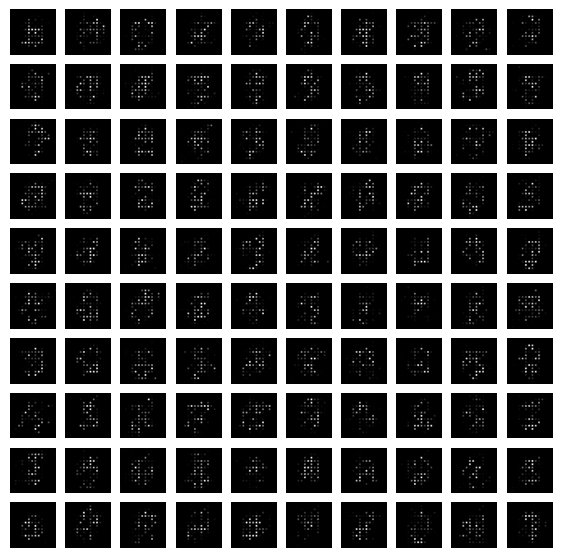

In [23]:
rand_vectors = [] # lista vetores
for col in latent_vectors.transpose(1,0): # percorre cada dimensão
    mu, sigma = col.mean(), col.std() # calcula media
    rand_vectors.append(sigma*torch.randn(1,100) + mu) # gera valores

rand_vectors = torch.cat(rand_vectors).transpose(1,0).to(device) # organiza e envia vetores
fig, ax = plt.subplots(10,10,figsize=(7,7)); ax = iter(ax.flat) # cria grade
for p in rand_vectors: # percorre os vetores
    img = model.decoder(p.reshape(1,64,3,3)).view(28,28) # decodifica vetor em imagem
    show(img, ax=next(ax)) # exibe a imagem gerada na grade